In [88]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
data_dir = '~/Code/data/processed/v0.2.0/'
files = ['train', 'test', 'predict']

In [90]:
train, test, predict = [pd.read_csv(f'{data_dir}{file}.csv') for file in files]

In [91]:
train.head()

,CODUSU,NRO_HOGAR,COMPONENTE,ANO4,TRIMESTRE,REGION,MAS_500,AGLOMERADO,PONDERA,CH03,...,ratio_ocupados,NBI_COBERTURA_PREVISIONAL,NBI_DIFLABORAL,NBI_HACINAMIENTO,NBI_SANITARIA,NBI_TENENCIA,NBI_TRABAJO_PRECARIO,NBI_VIVIENDA,NBI_ZONA_VULNERABLE,DESERTO
0,TQRMNOPQRHLOKOCDEHJGH00708317,1,3.0,2021,2,40,1.0,1.126002e+06,250,3.0,...,0.20,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,TQRMNOPQRHLOKOCDEHJGH00708317,1,4.0,2021,2,40,1.0,8.364406e+05,250,3.0,...,0.20,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,TQRMNOQRPHLMPNCDEIJAH00708318,1,4.0,2021,2,1,1.0,1.282728e+06,4724,3.0,...,0.20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,TQRMNOQXPHLMQQCDEIJAH00708322,1,2.0,2021,2,1,1.0,2.873265e+05,5515,3.0,...,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,TQRMNOQXPHLMQQCDEIJAH00708322,1,3.0,2021,2,1,1.0,7.972866e+05,5515,3.0,...,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Look for data leakage**

In [92]:
train[['ANO4', 'TRIMESTRE']].value_counts()

ANO4  TRIMESTRE
2021  2            1667
2022  2            1651
2021  3            1409
dtype: int64

In [93]:
test[['ANO4', 'TRIMESTRE']].value_counts()

ANO4  TRIMESTRE
2022  3            232
dtype: int64

In [94]:
predict[['ANO4', 'TRIMESTRE']].value_counts()

ANO4  TRIMESTRE
2022  4            3922
dtype: int64

In [95]:
test.CODUSU.any() in train.CODUSU

False

In [96]:
predict.CODUSU.any() in train.CODUSU

False

# Unique values of each column

In [97]:
for column in train.columns:
    unique_values = train[column].unique()
    print(f"Unique values in '{column}': {unique_values}")

Unique values in 'CODUSU': ['TQRMNOPQRHLOKOCDEHJGH00708317' 'TQRMNOQRPHLMPNCDEIJAH00708318'
 'TQRMNOQXPHLMQQCDEIJAH00708322' ... 'TQRMNOTXTHJNKMCDEIOAH00787008'
 'TQRMNORPPHJMMPCDEGJBF00783467' 'TQRMNORSSHJOLOCDEGPDJ00784079']
Unique values in 'NRO_HOGAR': [1 2 3 4]
Unique values in 'COMPONENTE': [ 3.  4.  2.  5.  7.  1.  6.  8. 11.  9. 12. 10. 14.]
Unique values in 'ANO4': [2021 2022]
Unique values in 'TRIMESTRE': [2 3]
Unique values in 'REGION': [40  1 43 41 44 42]
Unique values in 'MAS_500': [1. 0.]
Unique values in 'AGLOMERADO': [1126002.07580359  836440.6497176  1282727.86358604  287326.50812099
  797286.59801103   13595.7850086   951723.32263531  743549.68841968
  800032.38807438  390069.8944779   981723.63437629  985715.92794273
   57465.97098283  797668.56809141 2315147.67990575 1002547.38365077
  957329.41715222 1085084.48285329  363140.27899009  370478.59005616
 1343489.35178698  994445.57154477  653983.87739148  217635.68733551
 2083340.71942253  941134.93579667       0.    

# Description of numerical columns

In [98]:
num_cols = [
    'AGLOMERADO', 'PONDERA', 'CH06', 'IV2', 'II1', 'II2',
    'IX_TOT', 'IX_MEN10', 'CH06_jefx', 'ratio_ocupados'
    ]
print(train[num_cols].describe())

         AGLOMERADO       PONDERA         CH06          IV2          II1  \
count  4.727000e+03   4727.000000  4727.000000  4727.000000  4727.000000   
mean   7.704716e+05    532.133912    17.788238     3.493971     3.448276   
std    5.005734e+05   1052.353697     6.358440     3.861372     3.604116   
min    0.000000e+00     16.000000    14.000000     1.000000     1.000000   
25%    3.704786e+05    157.000000    15.000000     3.000000     3.000000   
50%    8.000324e+05    254.000000    16.000000     3.000000     3.000000   
75%    1.002547e+06    436.000000    18.000000     4.000000     4.000000   
max    2.315148e+06  20635.000000    86.000000    99.000000    99.000000   

               II2       IX_TOT     IX_MEN10    CH06_jefx  ratio_ocupados  
count  4727.000000  4727.000000  4727.000000  4727.000000     4727.000000  
mean      2.515549     4.700444     0.534589    47.765602        0.365665  
std       0.828580     1.778809     0.814606    11.294862        0.200685  
min       0

# Data distribution

In [101]:
cat_cols = ['NRO_HOGAR', 'COMPONENTE', 'REGION', 'CH03', 'CH07',
    'CH10', 'CH15', 'CH16', 'ESTADO', 'PP02E', 'CH09', 'CH11', 
    'PP02H', 'servicio_domestico', 'IV5',
    'IV12_2', 'II3', 'II4_1', 'II4_2', 'II4_3', 'V1', 'V2',
    'V21', 'V22', 'V3', 'V5', 'V6', 'V7', 'V8', 'V11', 'V12', 'V13', 'V14',
    'PP07I_jefx', 'APORTES_JUBILATORIOS_jefx', 'PP04B1_jefx',
    'REALIZADA_conyuge', 'CONYUGE_TRABAJA',
    'JEFA_MUJER', 'HOGAR_MONOP', 'NBI_COBERTURA_PREVISIONAL',
    'NBI_DIFLABORAL', 'NBI_HACINAMIENTO', 'NBI_SANITARIA', 'NBI_TENENCIA',
    'NBI_TRABAJO_PRECARIO', 'NBI_VIVIENDA', 'NBI_ZONA_VULNERABLE', 'DESERTO',
    'MAS_500', 'CH04', 'II8', 'IV6', 'IV7', 'IV9', 'IV11', 'CH08', 'TRIMESTRE',
    'NIVEL_ED', 'IV1', 'IV3', 'IV4', 'DECCFR',
    'ESTADO_jefx', 'NIVEL_ED_jefx', 'ANO4', 'II9', 'ESTADO_conyuge'
    ]

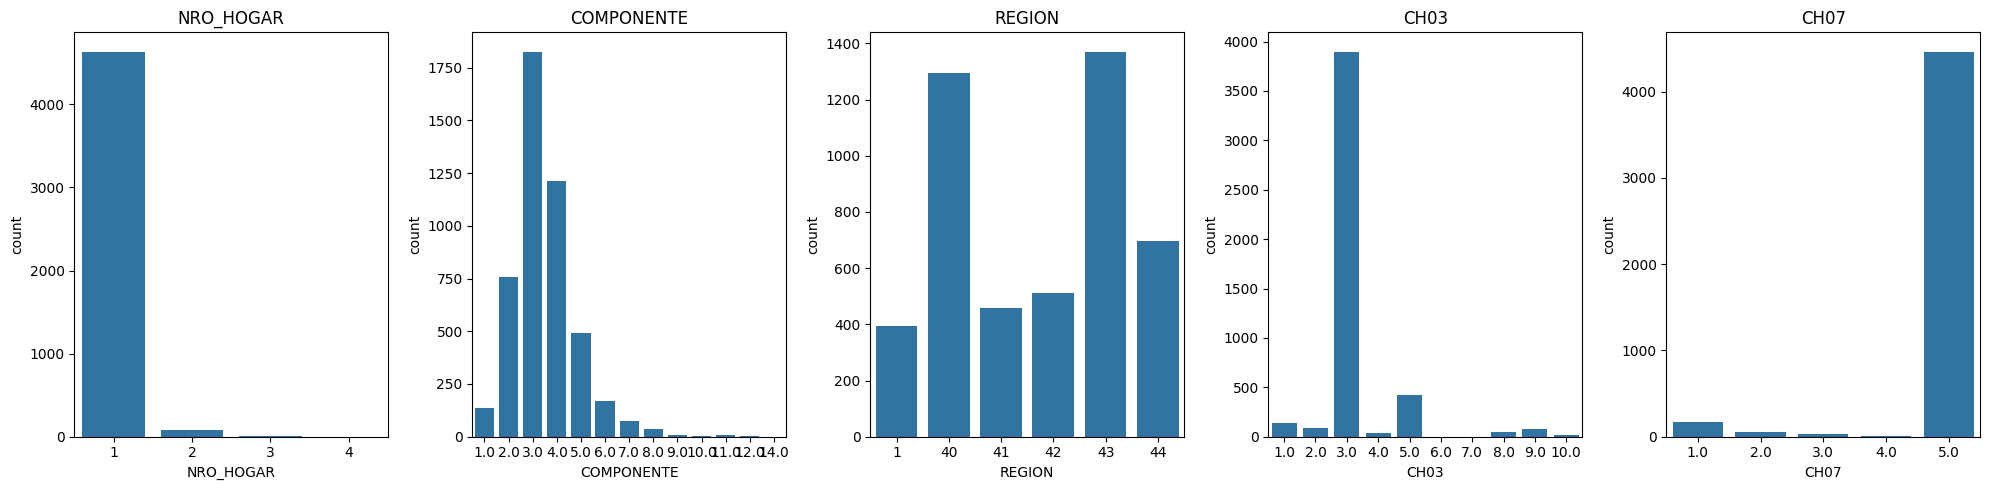

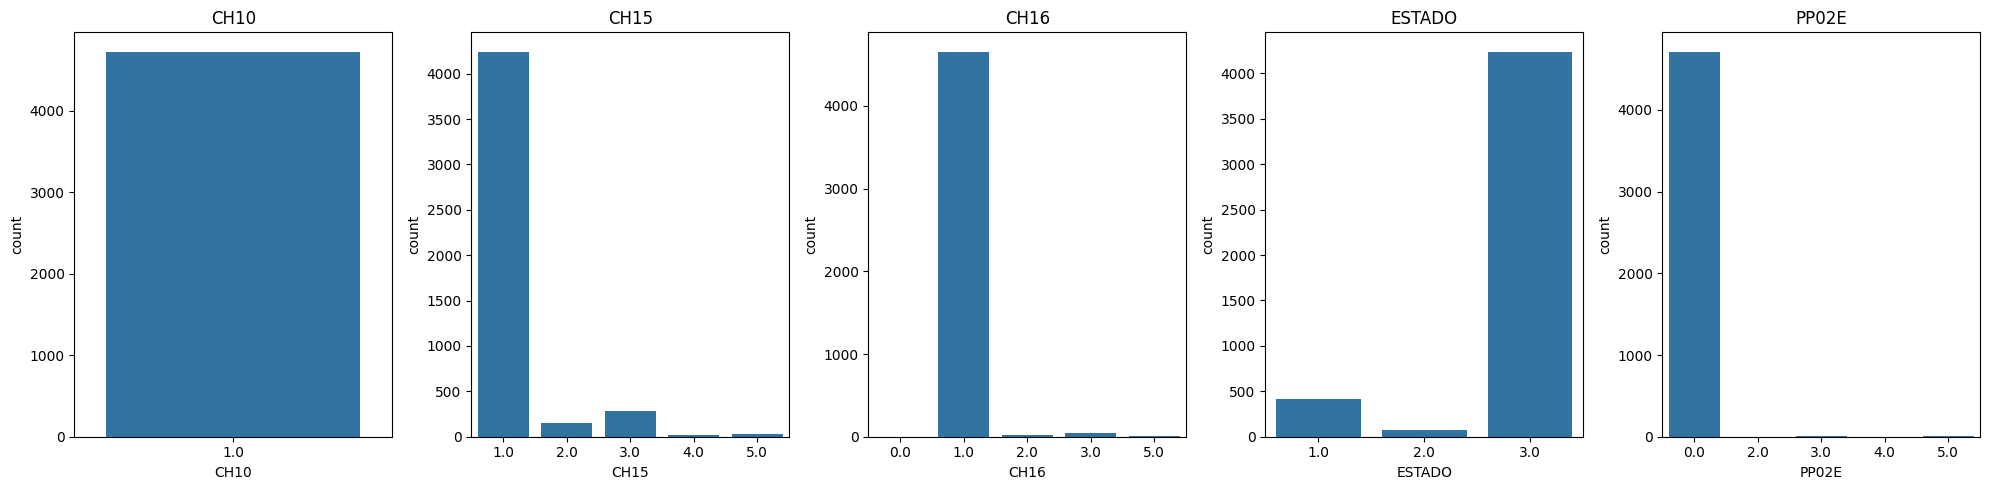

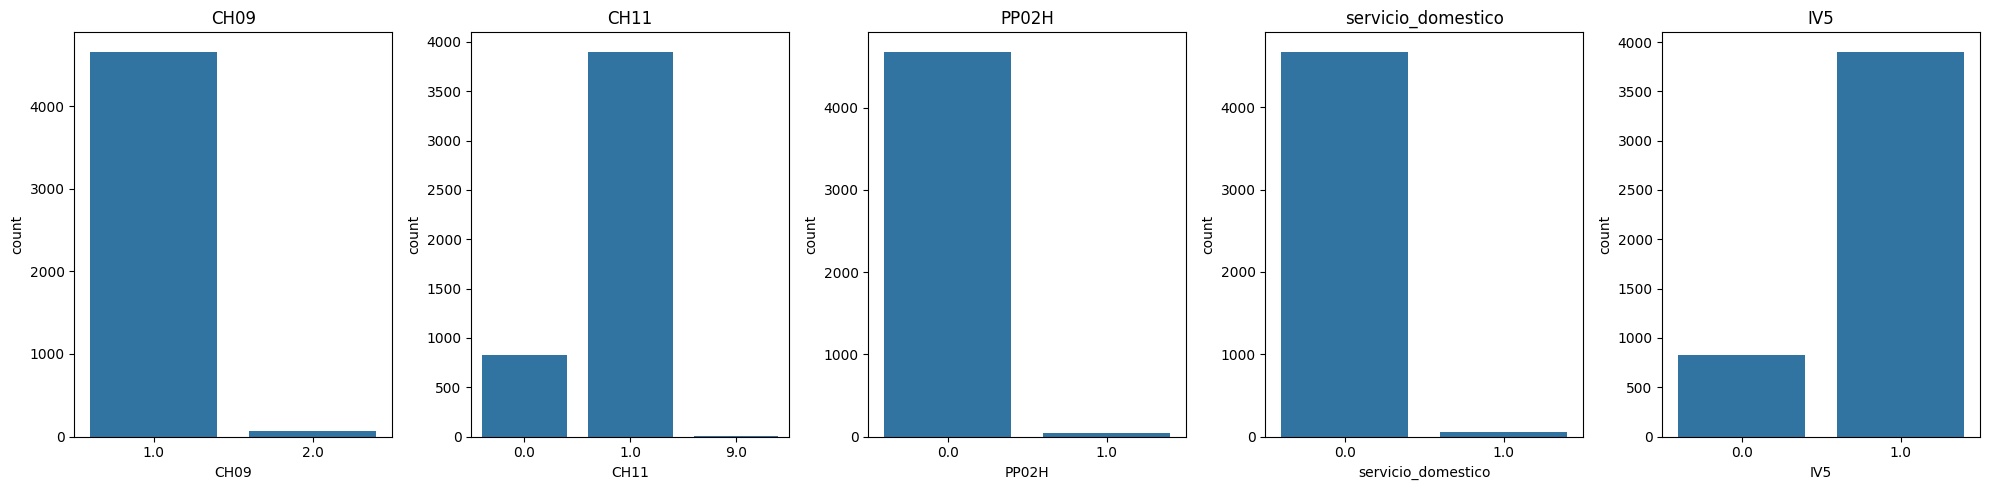

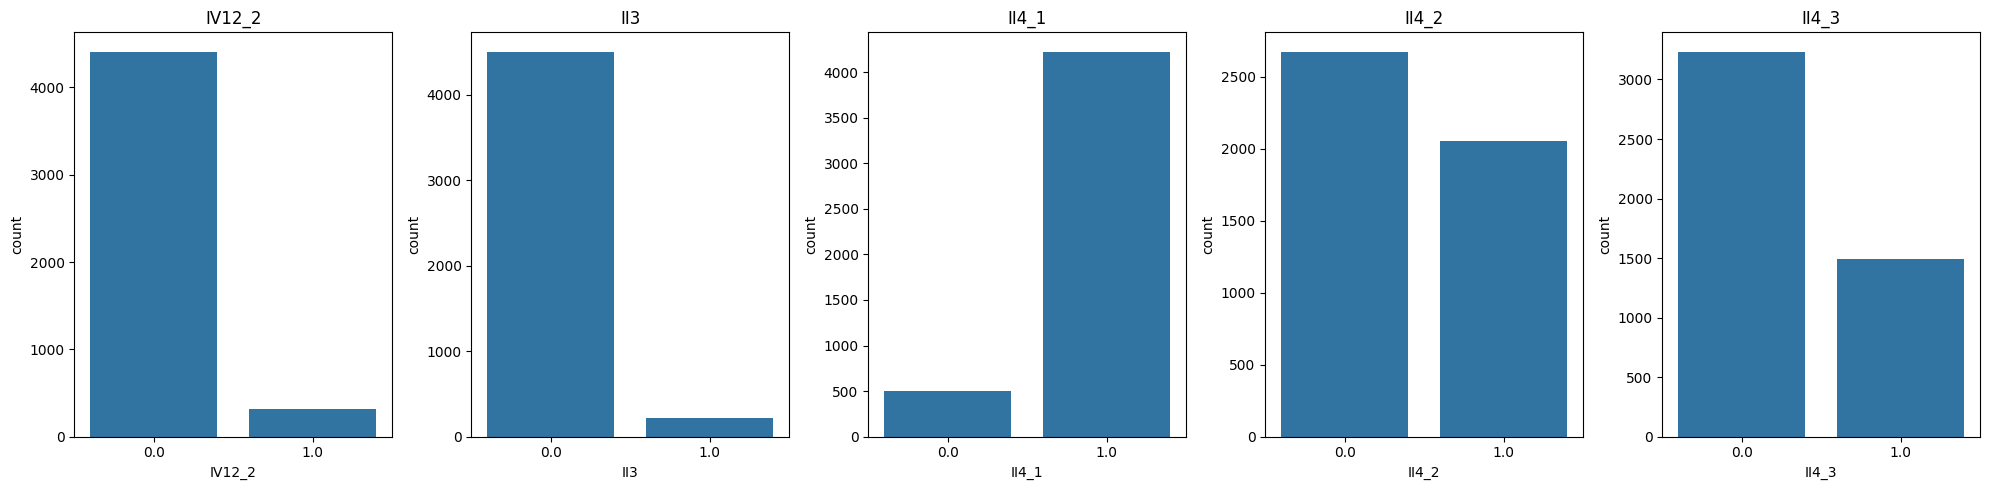

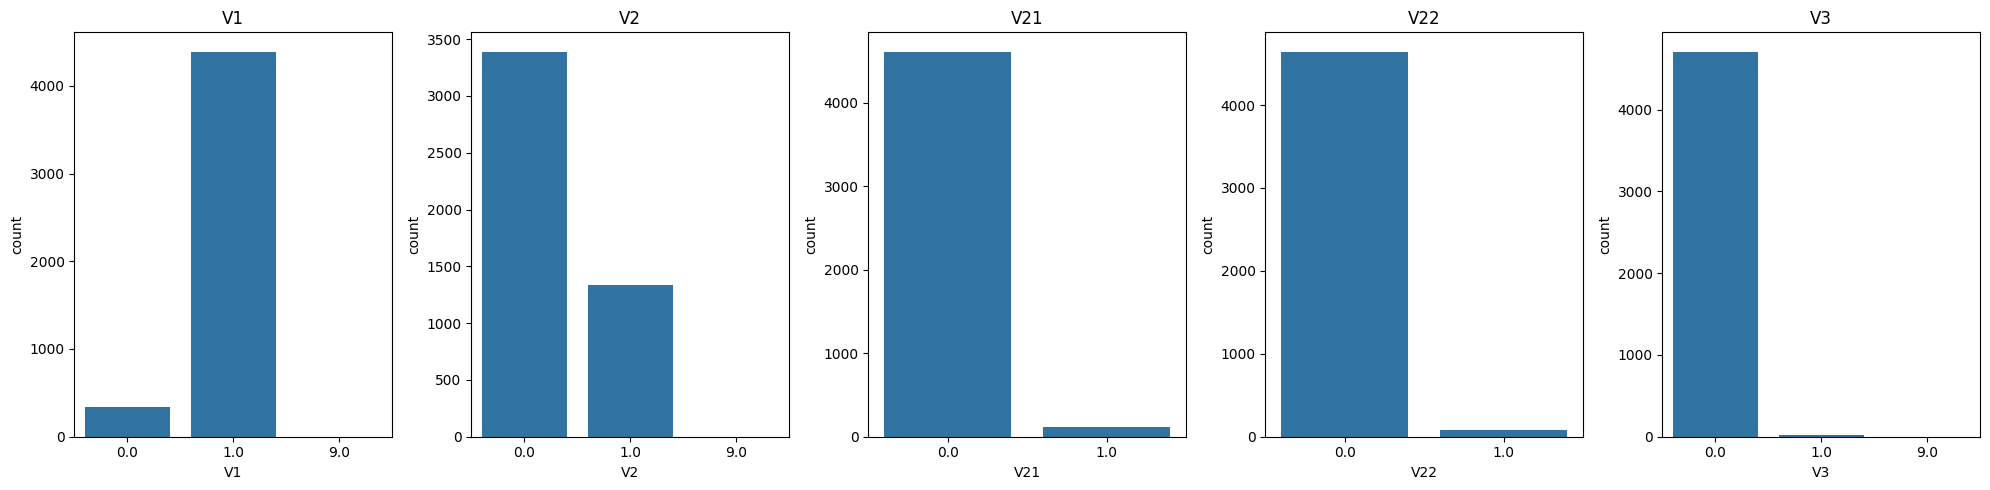

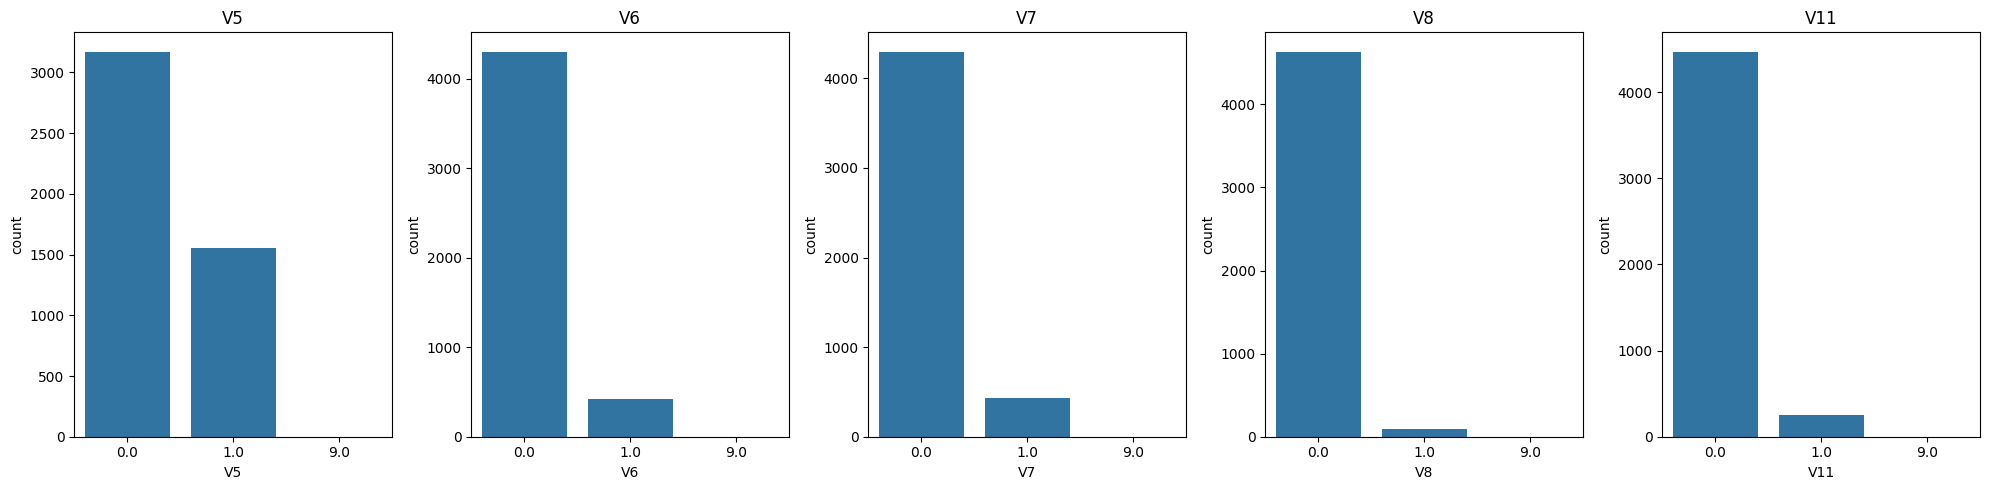

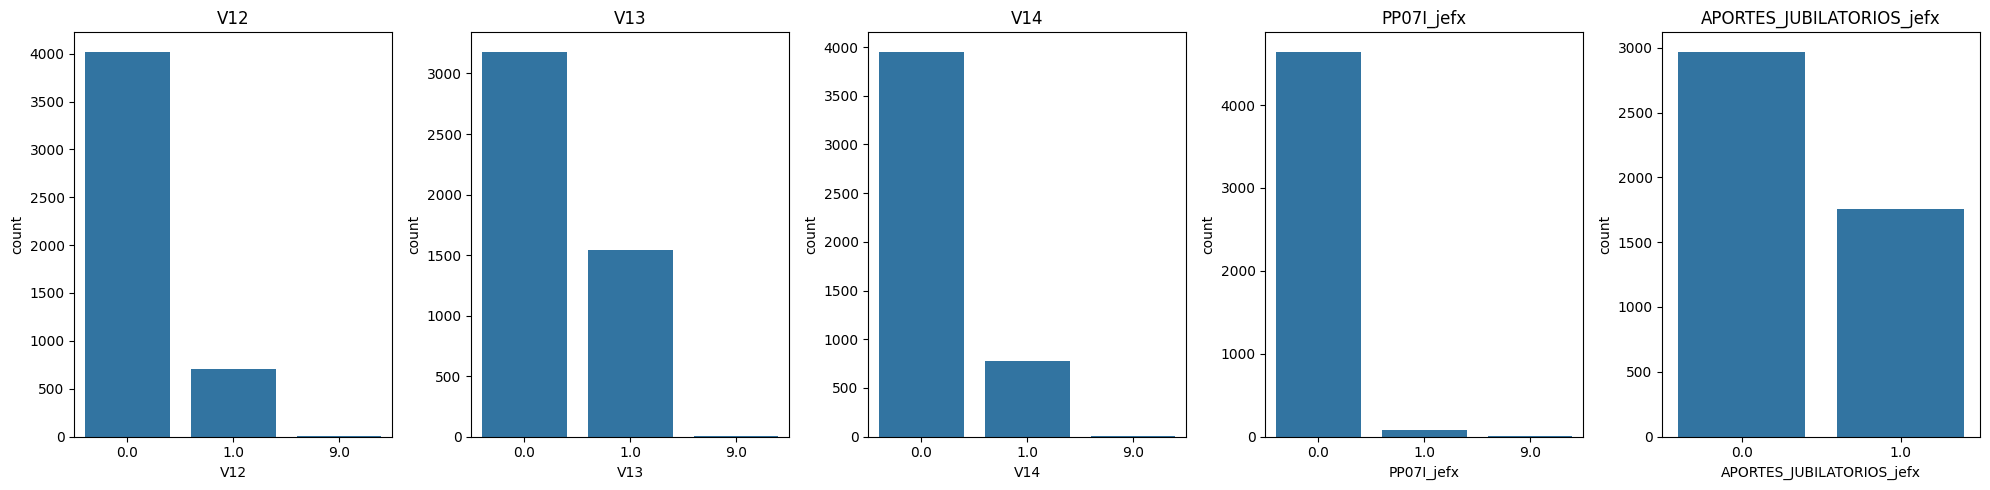

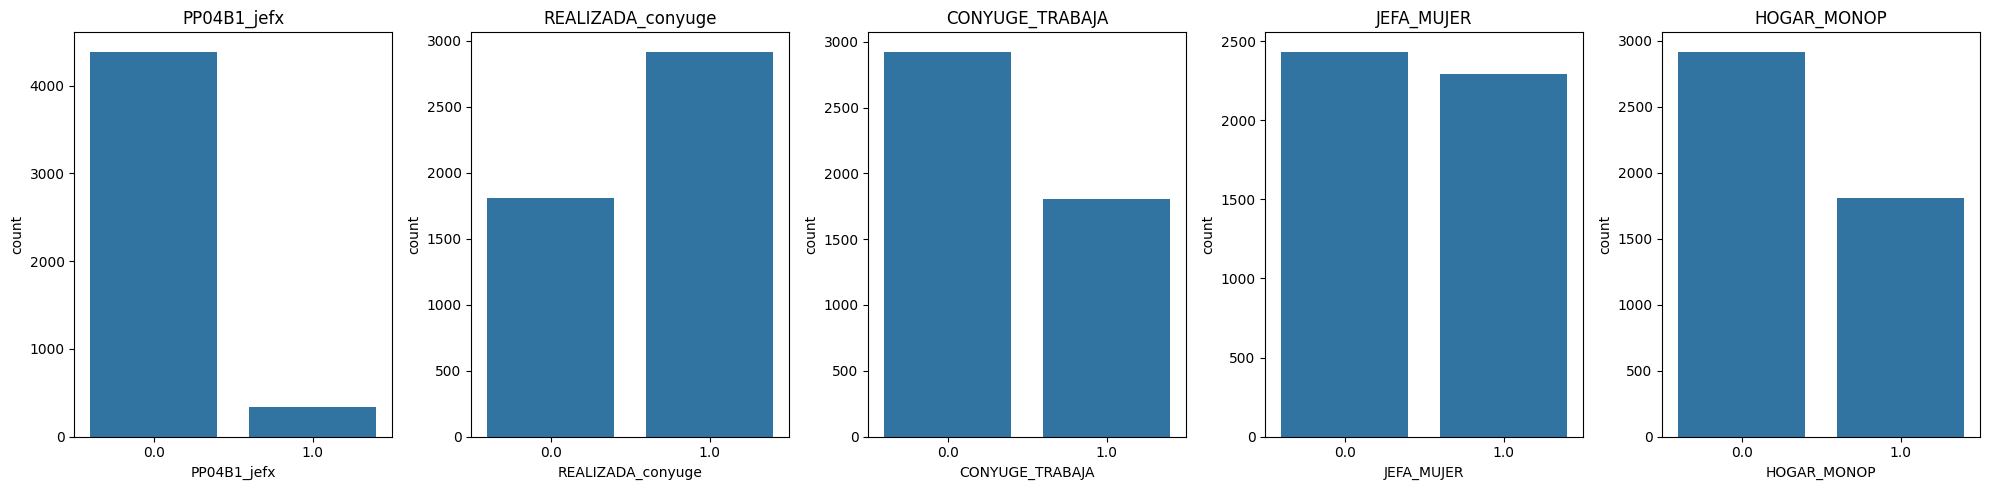

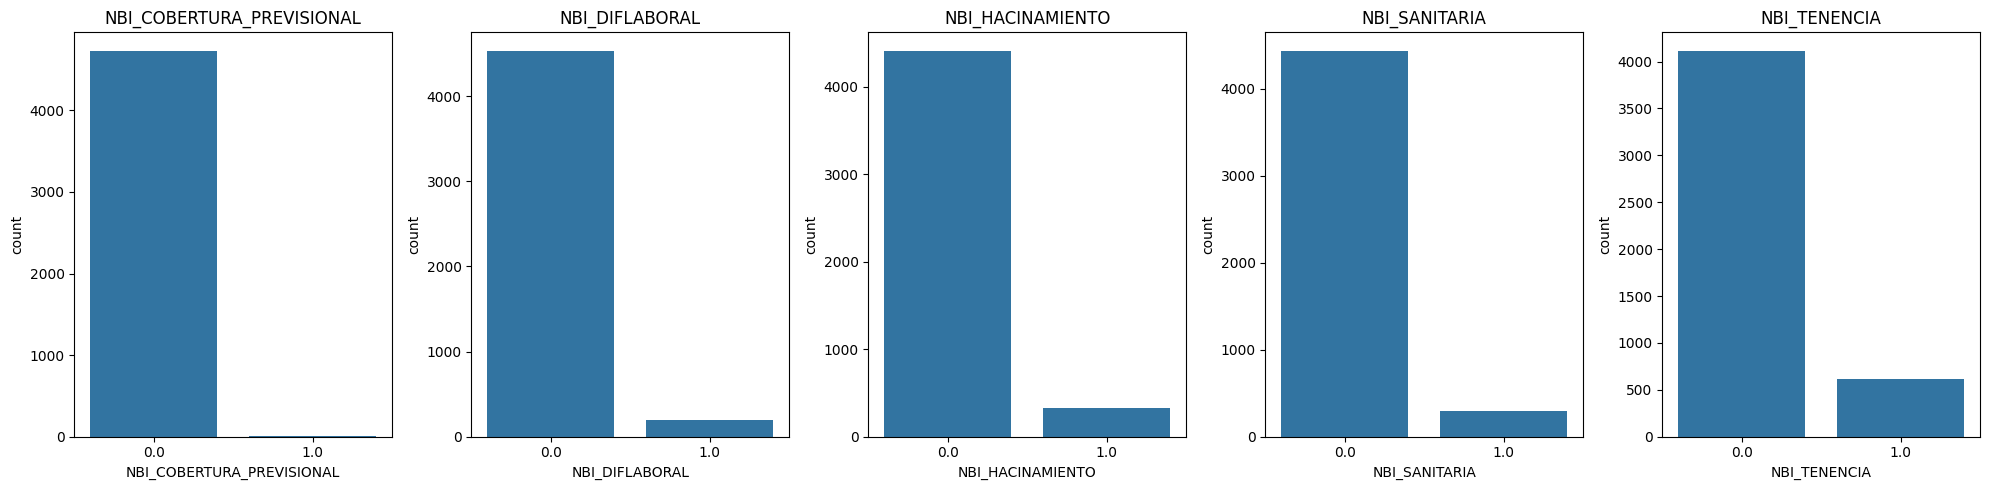

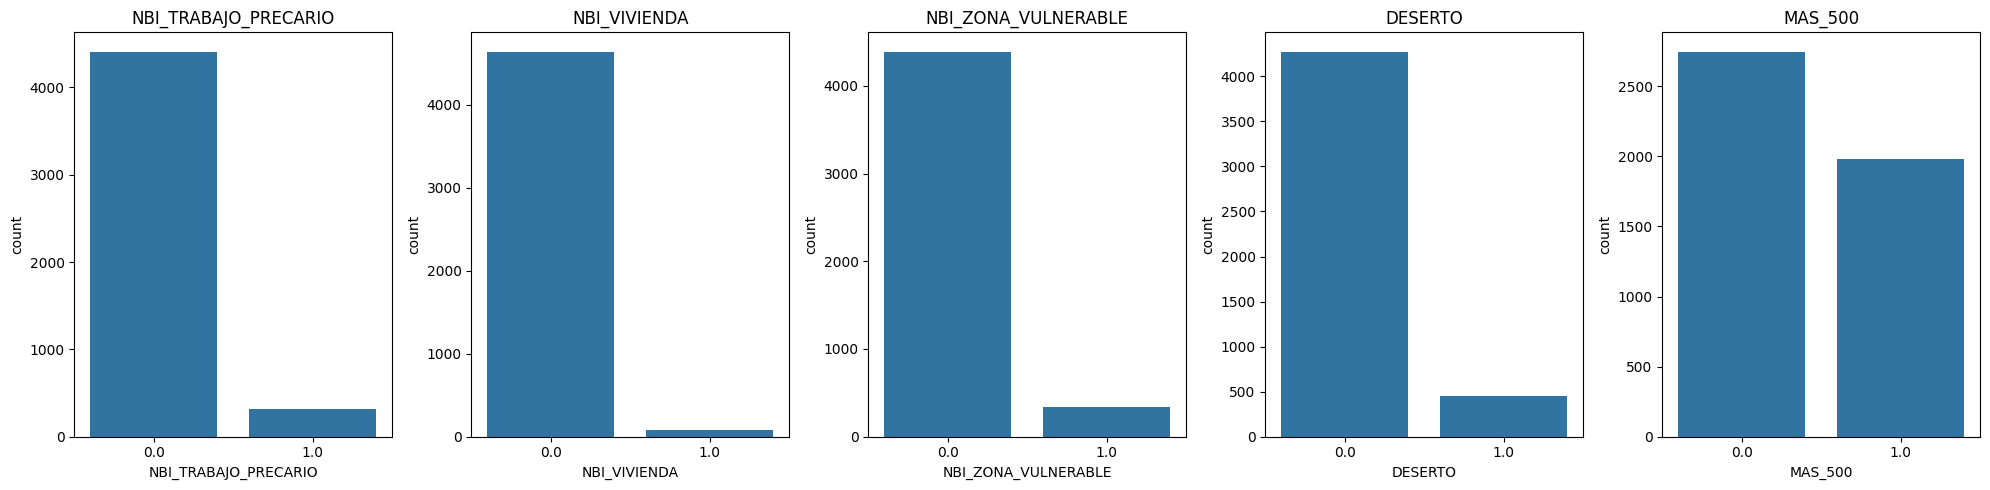

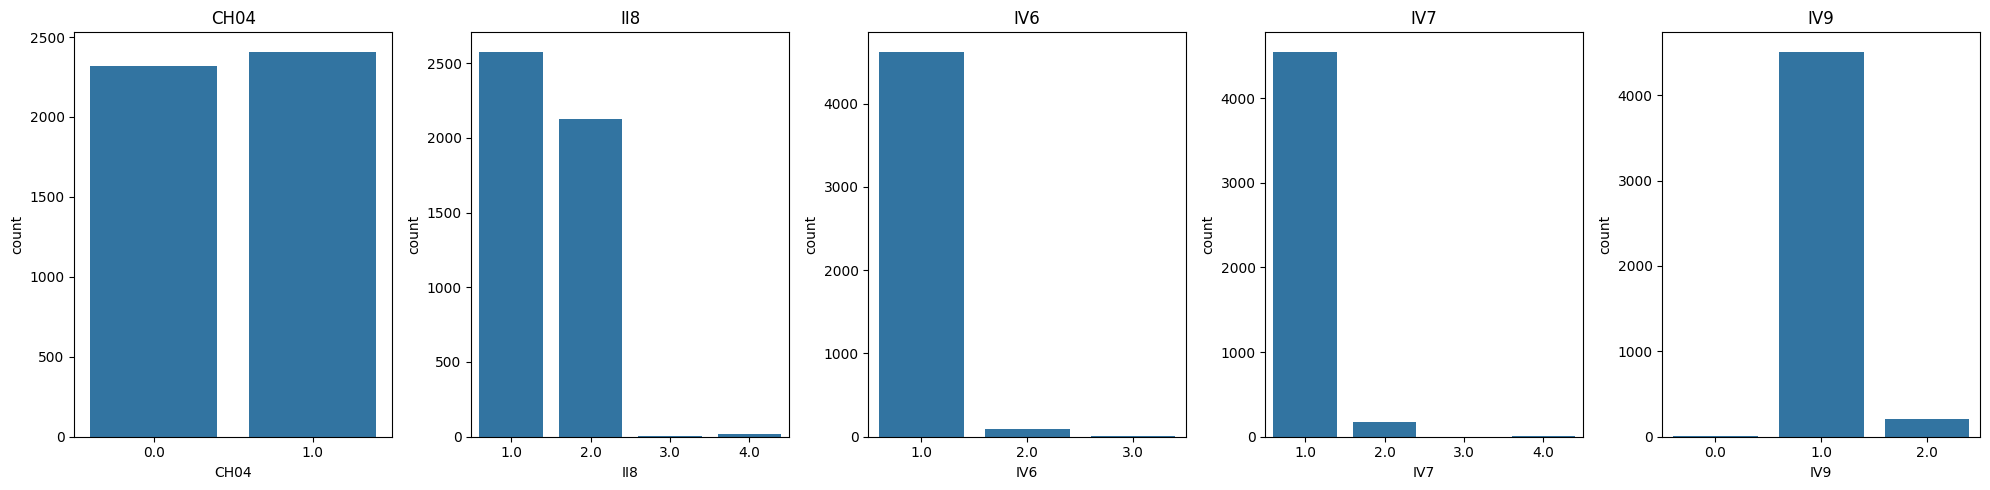

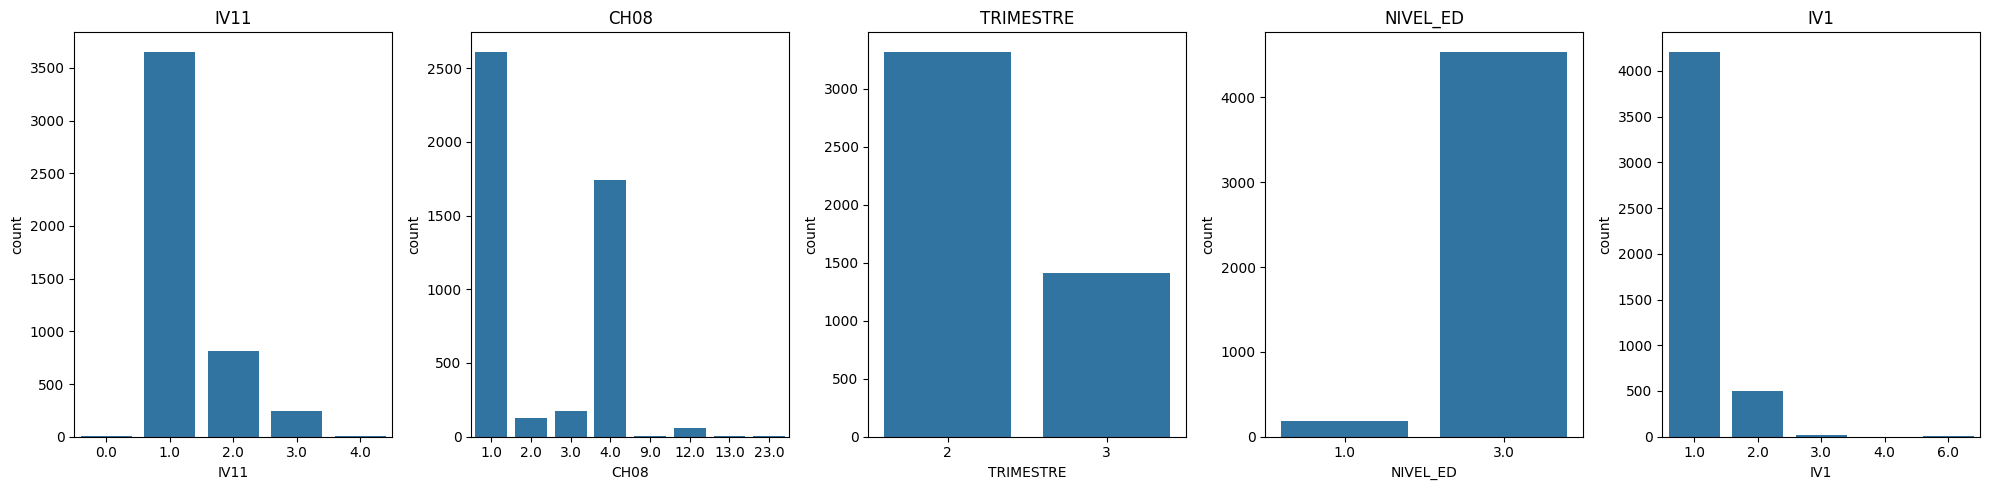

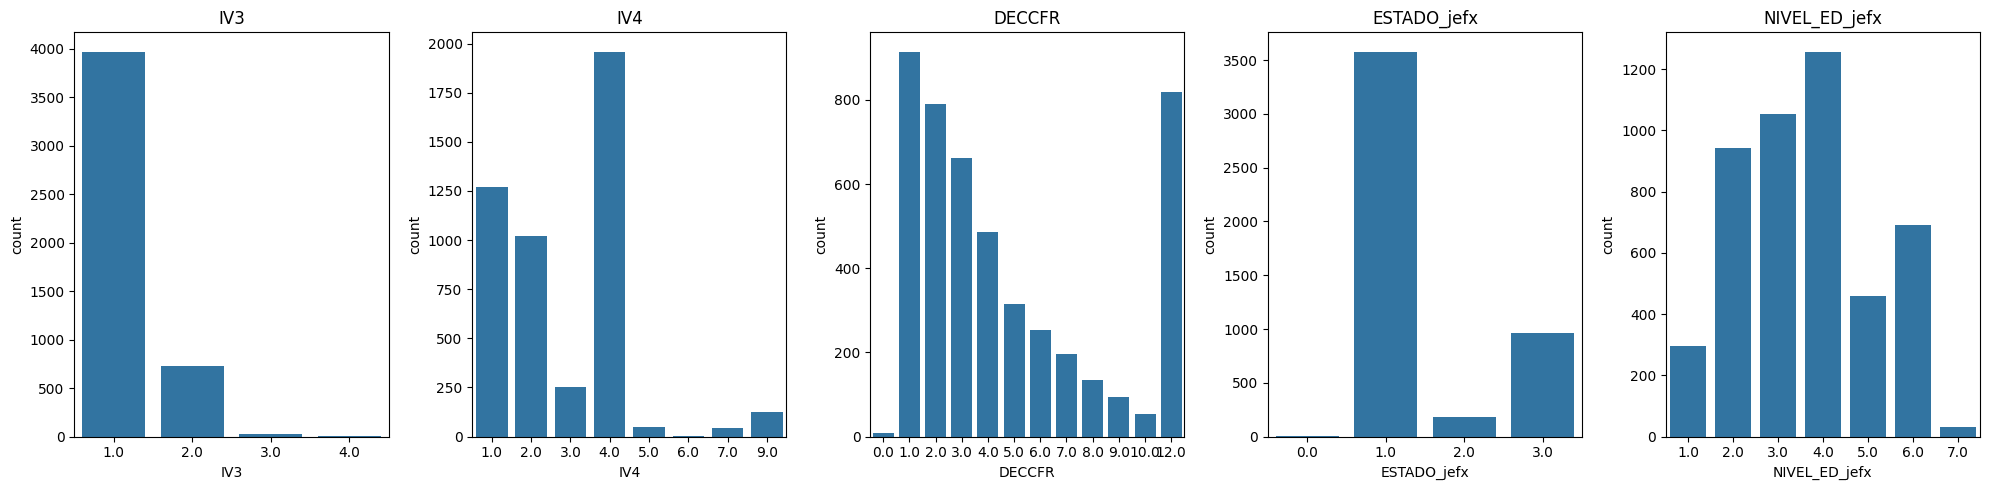

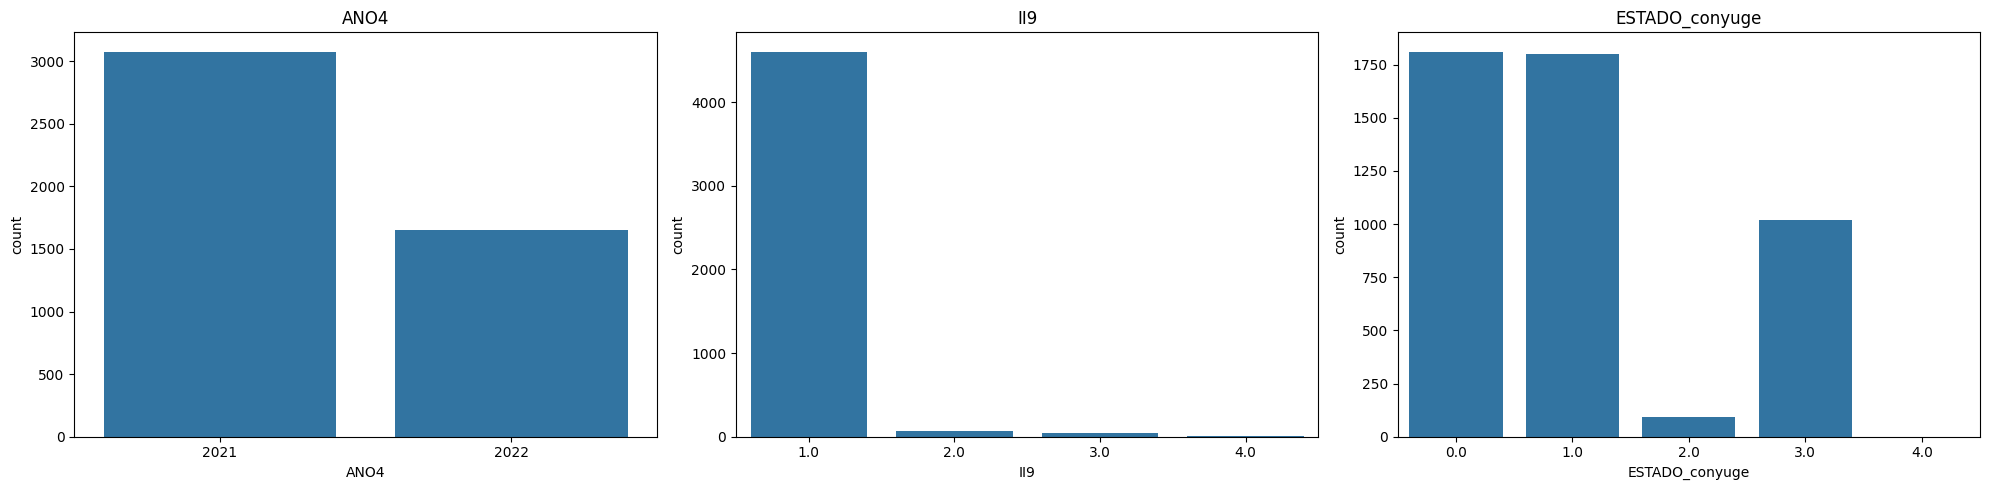

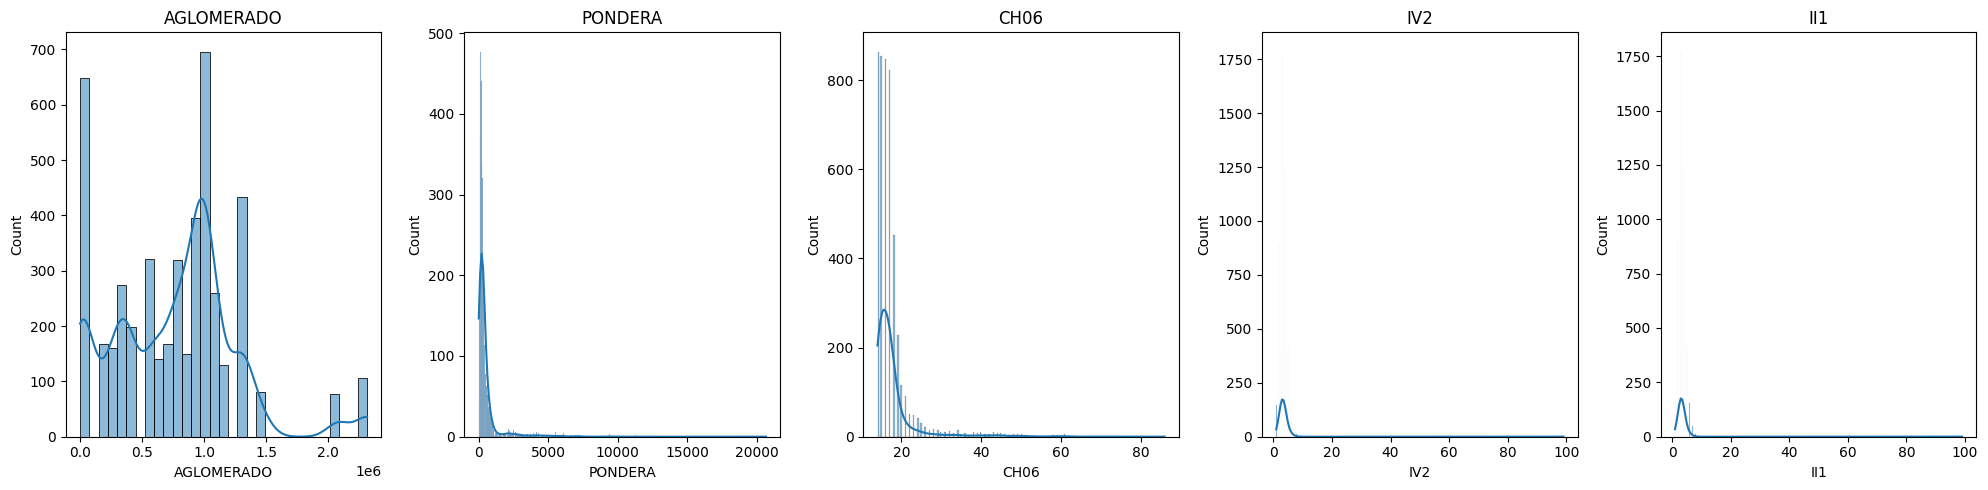

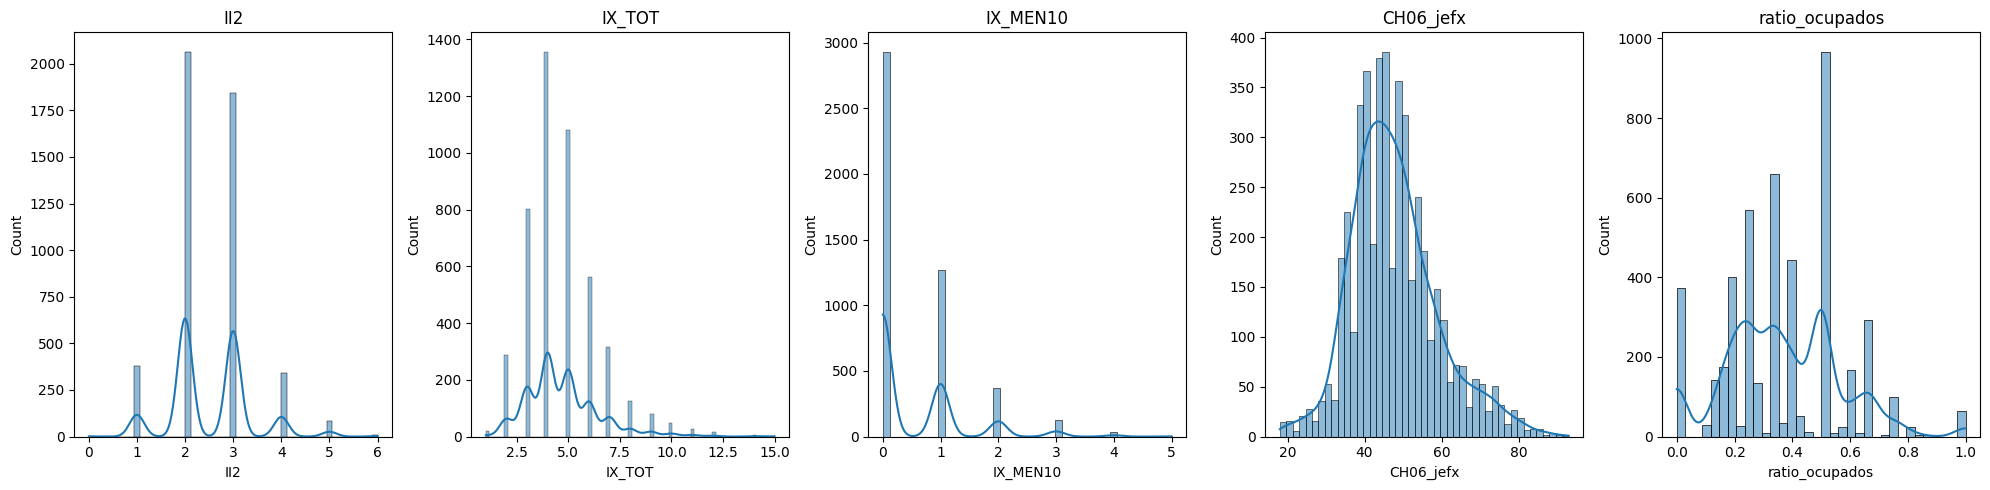

In [102]:
cols_per_row = 5

#Subgráficos por filas para las columnas categóricas
categorical_groups = [cat_cols[i:i+cols_per_row] for i in range(0, len(cat_cols), cols_per_row)]
for group in categorical_groups:
    fig, axs = plt.subplots(1, len(group), figsize=(20, 5))
    for i, col in enumerate(group):
        sns.countplot(data=train, x=col, ax=axs[i])
        axs[i].set_title(col)
    plt.tight_layout()
    plt.show()

# Crear subgráficos por filas para las columnas numéricas
numeric_groups = [num_cols[i:i+cols_per_row] for i in range(0, len(num_cols), cols_per_row)]
for group in numeric_groups:
    fig, axs = plt.subplots(1, len(group), figsize=(20, 5))
    for i, col in enumerate(group):
        sns.histplot(data=train, x=col, ax=axs[i], kde=True)
        axs[i].set_title(col)
    plt.tight_layout()
    plt.show()